# Fit extinction and parallax with priors

How much does the fitted SED change when foreground dust and distance can vary?
Use Gaia DR3 SB2 `858860697467058688` and the same absolute XP+2MASS fluxes in three fits:
fixed E=0 and parallax, fitted E at fixed parallax, and fitted E plus parallax.
Each case compares a single star with a coeval binary.

Run from `examples/`, after installing `pip install -e ".[download,dust,notebook]"` from the repository root.
The full Edenhofer posterior-sample map is about 19 GB; run this notebook on a server with enough memory.
Prepare it once using `dustmaps.edenhofer2023.fetch(fetch_samples=True)`.
The notebook loads an existing map and reuses cached observations.

## Load the observed SED

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from dustmaps.edenhofer2023 import Edenhofer2023Query
from sedkit import EdenhoferPrior, StellarModel, download, fit, plot

SOURCE_ID = "858860697467058688"
CACHE_DIR = Path("data")
OUTPUT_DIR = Path("results/extinction_parallax_20261003")
MAP_FNAME = None  # or "/path/to/edenhofer_2023/samples_healpix.fits"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sed = download(SOURCE_ID, cache_dir=CACHE_DIR)
model = StellarModel()
observations = sed.flux.copy(), sed.error.copy(), sed.mask.copy()
print(f"Catalogue parallax: {sed.parallax_mas:.6f} +/- {sed.parallax_error_mas:.6f} mas")
print(f"Catalogue distance: {1000 / sed.parallax_mas:.3f} pc; {sed.fit_mask().sum()} fitted channels")

Catalogue parallax: 10.976666 +/- 0.015278 mas
Catalogue distance: 91.102 pc; 64 fitted channels


## What enters the fit?

The observed fluxes and errors stay unchanged. The model is

`F_model = F_10pc * (parallax_mas / 100)**2 * exp(-E * k_lambda)`.

For a binary, `F_10pc` is the sum of both stellar components. Both share the same distance and dust.
Parallax rescales the whole SED; extinction dims short wavelengths more strongly.
E is the native ZGR23 extinction parameter, not E(B-V) or A_V; the extinction-curve shape is fixed.

`fit(sed)` fixes E=0 and fixes parallax at its catalogue value.
`fit_parallax=True` fits positive parallax within three catalogue standard deviations.
The catalogue constraint contributes `((parallax - parallax_catalogue) / sigma_parallax)**2` to the objective.
If the catalogue uncertainty is zero or absent, parallax remains fixed.
Age and metallicity are held at 5 Gyr and [M/H]=0 here so we can isolate the two options.

In [2]:
results = {}
results["fixed"] = fit(sed, model=model, age_gyr=5.0, feh=0.0)
for kind in ("single", "binary"):
    assert results["fixed"][kind]["parallax_mas"] == sed.parallax_mas
print("Baseline: E=0, catalogue parallax fixed.")

Baseline: E=0, catalogue parallax fixed.


## Load the Edenhofer prior once

At the source coordinates and distance, the integrated map gives a mean E and its sample standard deviation.
`EdenhoferPrior` uses these as a Gaussian truncated at E=0.
With fitted parallax, it queries the map at each trial distance `1000 / parallax_mas` pc;
the width and truncation normalization are retained as the distance changes.
Do not use density uncertainties from a mean-only map as integrated-extinction uncertainties.

In [3]:
query = Edenhofer2023Query(map_fname=MAP_FNAME, integrated=True, load_samples=True)
prior = EdenhoferPrior(query)
mean_e, sigma_e = prior.moments(sed.metadata["ra"], sed.metadata["dec"],
                               1000 / sed.parallax_mas)
print(f"Dust prior at catalogue distance: E = {mean_e:.6f}, width = {sigma_e:.6f}")

Integrating extinction map (this might take a couple of minutes)...


Optimizing map for querying (this might take a couple of seconds)...


Dust prior at catalogue distance: E = 0.007219, width = 0.000516


## Fit E at fixed parallax, then fit both

`extinction=None` releases E and applies the supplied dust prior.
Keep one prior instance in memory and reuse it for all fits.
The same catalogue and dust constraints apply under the single and binary hypotheses.

In [4]:
results["dust_fixed"] = fit(
    sed, model=model, age_gyr=5.0, feh=0.0,
    extinction=None, dust_prior=prior,
)
results["dust_joint"] = fit(
    sed, model=model, age_gyr=5.0, feh=0.0,
    extinction=None, dust_prior=prior, fit_parallax=True,
)
print("Completed fixed-distance dust fit and joint extinction/parallax fit.")

Completed fixed-distance dust fit and joint extinction/parallax fit.


## Compare fitted parameters

`chi2` describes the SED residuals with the model covariance.
`m2lnl` also includes the covariance determinant; `objective` adds the prior terms.
Within each case, `delta = objective_single - objective_binary` measures the penalized fit preference.
It is not a binary probability or a marginalized Bayes factor.
Absolute objectives from different fixed/free parameter setups are not model-selection odds.

In [5]:
rows = []
for case, result in results.items():
    for kind in ("single", "binary"):
        r = result[kind]
        rows.append(dict(case=case, kind=kind, m1=r["m1"], q=r["q"],
                         E=r["extinction_e"], parallax_mas=r["parallax_mas"],
                         parallax_shift_sigma=(r["parallax_mas"] - sed.parallax_mas) / sed.parallax_error_mas,
                         dust_mean=r["dust_prior_mean"] if r["dust_prior_mean"] is not None else np.nan,
                         dust_width=r["dust_prior_sigma"] if r["dust_prior_sigma"] is not None else np.nan,
                         chi2=r["chi2"], objective=r["objective"],
                         converged=r["converged"], at_bounds=", ".join(r["at_bounds"])))
summary = Table(rows=rows)
for name in ("m1", "q", "E", "parallax_mas", "dust_mean", "dust_width"):
    summary[name].format = ".6f"
for name in ("parallax_shift_sigma", "chi2", "objective"):
    summary[name].format = ".3f"
summary.write(OUTPUT_DIR / "summary.csv", overwrite=True)
for case, result in results.items():
    print(f"{case:12s} single minus binary objective: {result['delta']:.3f}")
summary

fixed        single minus binary objective: 1002.070
dust_fixed   single minus binary objective: 925.431
dust_joint   single minus binary objective: 916.438


case,kind,m1,q,E,parallax_mas,parallax_shift_sigma,dust_mean,dust_width,chi2,objective,converged,at_bounds
str10,str6,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,str1
fixed,single,0.941783,0.000000,0.000000,10.976666,0.000,nan,nan,1083.155,1466.038,True,
fixed,binary,0.862456,0.928998,0.000000,10.976666,0.000,nan,nan,82.313,463.967,True,
dust_fixed,single,0.944504,0.000000,0.008558,10.976666,0.000,0.007219,0.000516,993.436,1367.881,True,
dust_fixed,binary,0.866199,0.924755,0.007300,10.976666,0.000,0.007219,0.000516,75.914,442.450,True,
dust_joint,single,0.943142,0.000000,0.008533,11.022377,2.992,0.007215,0.000515,975.617,1358.807,True,
dust_joint,binary,0.866282,0.924271,0.007298,10.981002,0.284,0.007219,0.000516,75.753,442.369,True,


## View the absolute-flux SEDs

Each panel shows the same observations. Compare how the red single-star and blue binary models move.
The lower panels use the plotting API's logarithmic flux ratio to the single model; see the axis labels.

[SED PNG](results/extinction_parallax_20261003/sed_comparison.png), [PDF](results/extinction_parallax_20261003/sed_comparison.pdf), [Python source](05_extinction_parallax.py).

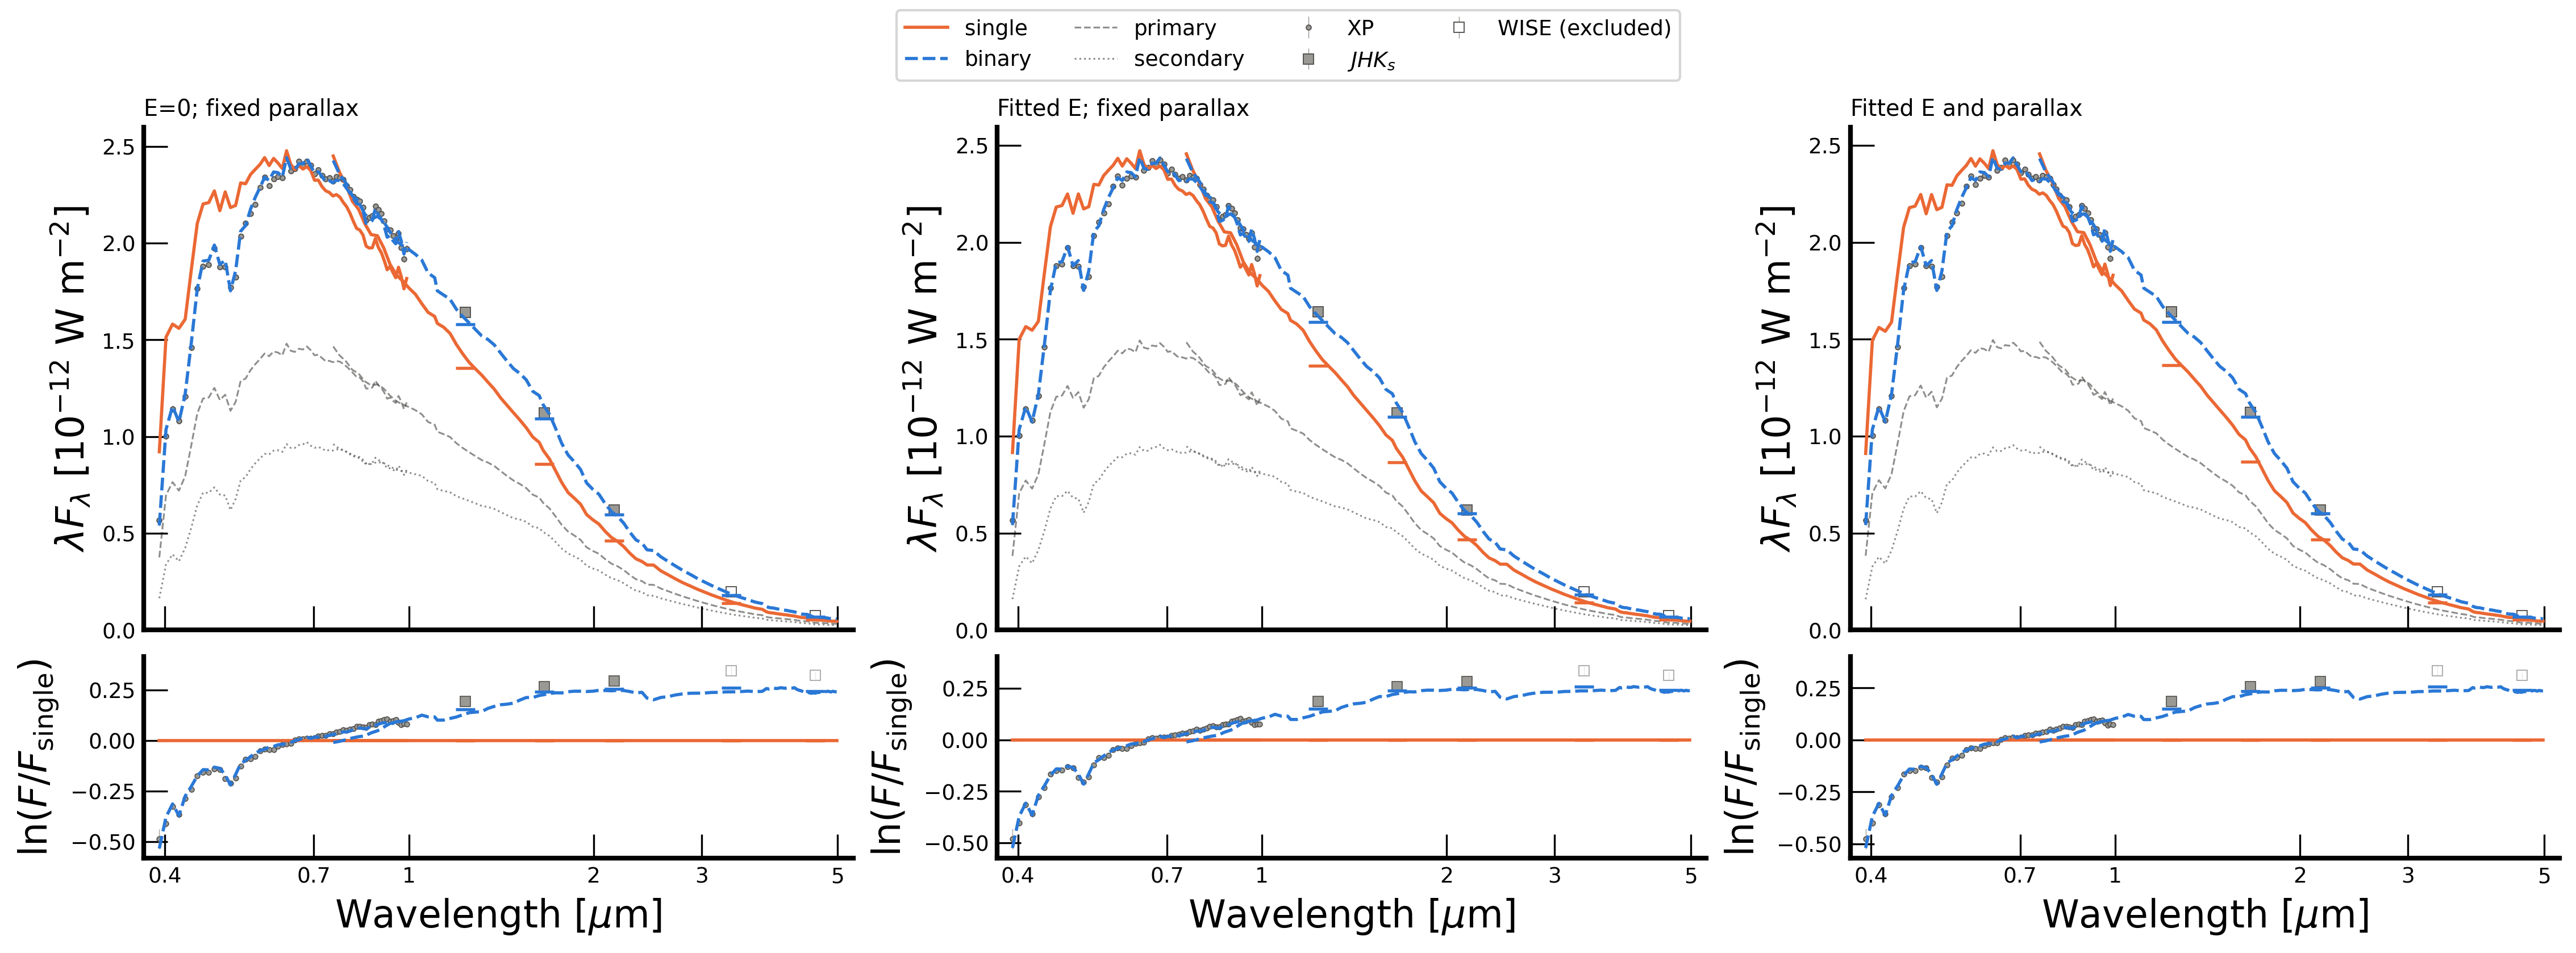

In [6]:
titles = {"fixed": "E=0; fixed parallax", "dust_fixed": "Fitted E; fixed parallax",
          "dust_joint": "Fitted E and parallax"}
fig, axes = plt.subplots(2, 3, figsize=(15, 5.5), sharex=True,
                         gridspec_kw={"height_ratios": [2.5, 1]}, layout="constrained")
for j, (case, result) in enumerate(results.items()):
    plot(sed, result, axes=axes[:, j], title=titles[case])
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside upper center", ncol=4, fontsize=9)
fig.savefig(OUTPUT_DIR / "sed_comparison.png", dpi=180)
fig.savefig(OUTPUT_DIR / "sed_comparison.pdf")
plt.show()

## View the two priors and the fitted points

Left: the catalogue parallax Gaussian, in units of its uncertainty. The fitted search is limited to +/-3 sigma.
Right: the E prior evaluated at each joint solution's distance. Vertical lines are best fits.
These curves are input priors, not fitted posterior distributions.
`dust_prior_sigma` is a map-prior width, not an uncertainty on the fitted E.

[Prior PNG](results/extinction_parallax_20261003/priors.png), [PDF](results/extinction_parallax_20261003/priors.pdf), [Python source](05_extinction_parallax.py).

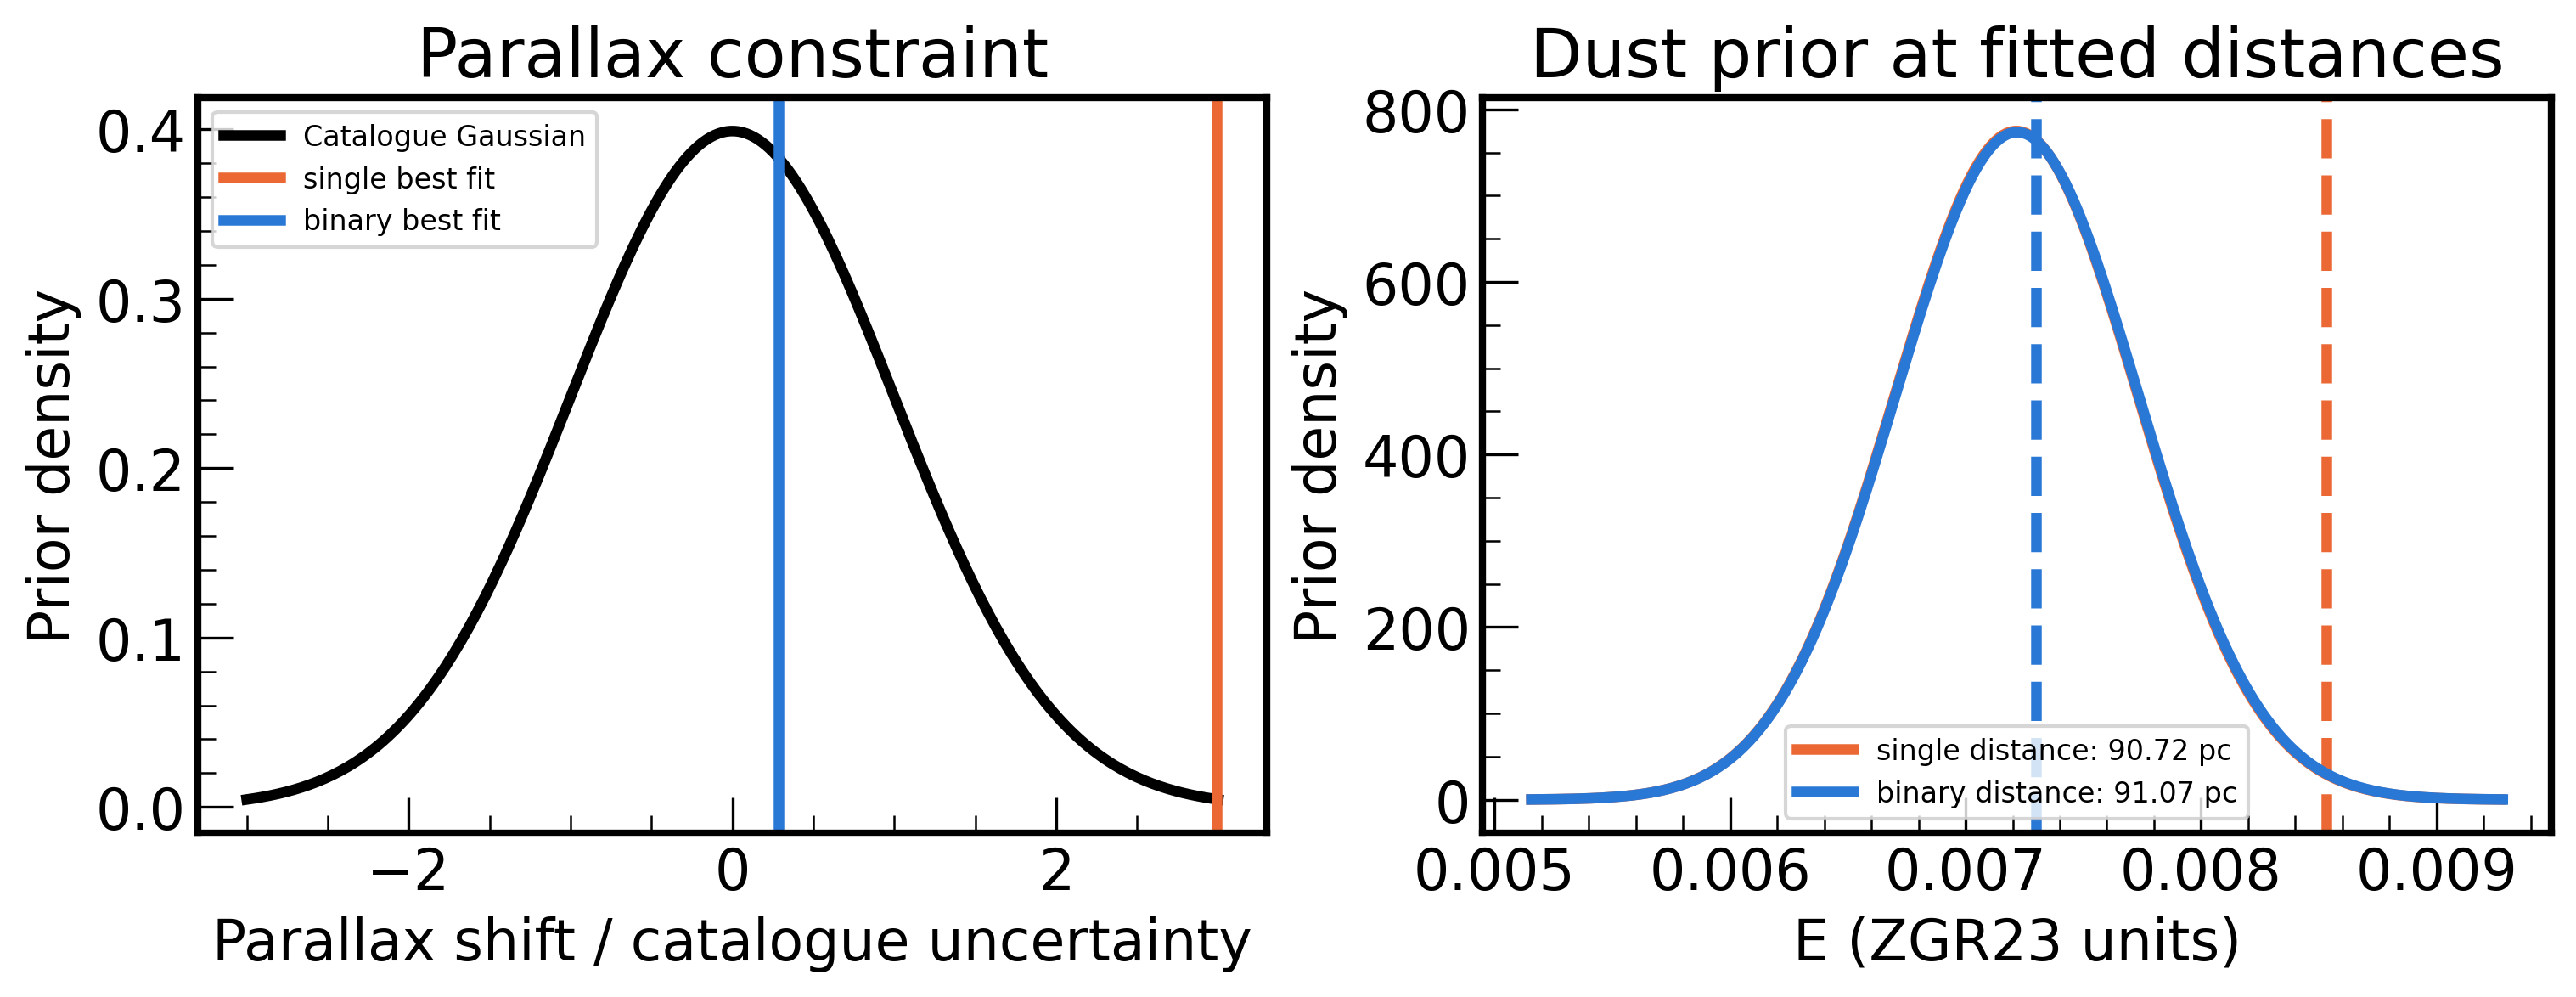

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout="constrained")
z_grid = np.linspace(-3, 3, 250)
axes[0].plot(z_grid, np.exp(-0.5 * z_grid**2) / np.sqrt(2*np.pi), color="black",
             label="Catalogue Gaussian")
for kind, color in (("single", "#eb6834"), ("binary", "#2a78d6")):
    r = results["dust_joint"][kind]
    z = (r["parallax_mas"] - sed.parallax_mas) / sed.parallax_error_mas
    axes[0].axvline(z, color=color, label=f"{kind} best fit")
    mean, width = r["dust_prior_mean"], r["dust_prior_sigma"]
    e_grid = np.linspace(max(0, mean - 4*width), max(mean + 4*width, r["extinction_e"] + width), 250)
    pdf = np.exp(-0.5 * np.array([prior.penalty(e, mean, width) for e in e_grid])) / np.sqrt(2*np.pi)
    axes[1].plot(e_grid, pdf, color=color,
                 label=f"{kind} distance: {1000 / r['parallax_mas']:.2f} pc")
    axes[1].axvline(r["extinction_e"], color=color, ls="--")
axes[0].set(xlabel="Parallax shift / catalogue uncertainty", ylabel="Prior density", title="Parallax constraint")
axes[1].set(xlabel="E (ZGR23 units)", ylabel="Prior density", title="Dust prior at fitted distances")
for ax in axes:
    ax.legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "priors.png", dpi=180)
fig.savefig(OUTPUT_DIR / "priors.pdf")
plt.show()

## Check the objective and unchanged observations

For the joint fit, `objective = m2lnl + parallax_penalty + dust_prior_penalty`.
The dust penalty includes its distance-dependent normalization and can be negative.
A single star and binary use identical observation masks.

In [8]:
for old, current in zip(observations, (sed.flux, sed.error, sed.mask)):
    np.testing.assert_array_equal(old, current)
for result in results.values():
    np.testing.assert_array_equal(result["single"]["mask"], result["binary"]["mask"])
for kind in ("single", "binary"):
    r = results["dust_joint"][kind]
    z = (r["parallax_mas"] - sed.parallax_mas) / sed.parallax_error_mas
    np.testing.assert_allclose(r["objective"], r["m2lnl"] + z*z + r["dust_prior_penalty"])
for kind in ("single", "binary"):
    assert results["dust_fixed"][kind]["parallax_mas"] == sed.parallax_mas
b_fixed, b_joint = results["dust_fixed"]["binary"], results["dust_joint"]["binary"]
print(f"Binary q: {b_fixed['q']:.6f} (fixed parallax) -> {b_joint['q']:.6f} (joint)")
print(f"Joint binary E: {b_joint['extinction_e']:.6f}; parallax: {b_joint['parallax_mas']:.6f} mas")
print("Observation arrays unchanged; shared masks and objective decomposition verified.")

Binary q: 0.924755 (fixed parallax) -> 0.924271 (joint)
Joint binary E: 0.007298; parallax: 10.981002 mas
Observation arrays unchanged; shared masks and objective decomposition verified.


## Interpretation and limits

This nearby target has little extinction and a precise parallax. Releasing parallax changes binary q
from 0.924755 to 0.924271; its parallax moves by only 0.284 catalogue sigma.
The single-star fit moves by 2.992 sigma, close to the permitted upper limit.
These conditional best fits do not establish mass-ratio accuracy.
Results depend on the fixed age and metallicity, stellar model, covariance, and extinction curve.
The Edenhofer map uses Gaia XP-based extinction estimates, so the dust prior is not fully independent
of these SED data. `fit` returns constrained best fits, not posterior samples.

For your own target, change `SOURCE_ID` and use the catalogue uncertainty in `sed.parallax_error_mas`.
Keep `fit_parallax=False` to fix distance. Use a numeric `extinction=0.1` to fix E without a map.
Unsupported map distances raise an error rather than implying zero extinction.
See [the extinction method](../docs/extinction.md) and [the fit API](../docs/api.md).

## Try one change

How would you release age and metallicity as well, while keeping both priors?

Set `age_gyr=None` and `feh=None`; this adds stellar-parameter degeneracies and costs more time:

```python
free_stellar = fit(sed, model=model, age_gyr=None, feh=None,
                   extinction=None, dust_prior=prior, fit_parallax=True)
```

Start with the three fits above before adding these freedoms.